# Trajectory Analysis for Ablation

In [11]:
0

0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
import pickle
import itertools
import torch
import tqdm
import scvi
import h5py
from scipy import stats
from scipy.stats import t
import math, gc
from typing import Mapping, Any

import scvelo as scv
import cellrank as cr
import scanpy.external as sce

scv.settings.verbosity = 3
cr.settings.verbosity = 2
sc.settings.verbose = 3

In [4]:
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)
sys.path.append("/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments")

from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

from incremental_training.helper.constants import metrics_scib, metric_direction_dict
from incremental_training.helper.plot_metrics_gridspec import plot_metrics_gridspec
from tardis_weight_scan.helper.plotting import plot_summary_ci, plot_umap_grid, normalize_and_align, annotate_points_on_line

2025-05-13 20:13:55.000 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-05-13 20:13:55.001 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [5]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

from matplotlib.ticker import NullFormatter
import matplotlib.ticker as mtick
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import colorcet as cc
from matplotlib.ticker import FormatStrFormatter
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
print(f"CUDA used: {torch.cuda.is_available()}")

dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

CUDA used: True


In [7]:
list_of_latents_path = os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_gene_cell_sctram_runs.pkl")
with open(list_of_latents_path, "rb") as _file_definitions:
    list_of_latents = pickle.load(_file_definitions)    

In [8]:
list_of_latents[0],list_of_latents[-1]

(['scvi_dentategyrus_gene',
  'none',
  0.0,
  '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/scvi_dentategyrus_ablation_gene_fraction_0.0_seed1.h5ad',
  1],
 ['scvi_dentategyrus_cell',
  'Granule|CA1-Sub|OPC',
  1.0,
  '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/scvi_dentategyrus_ablation_cell_Granule|CA1-Sub|OPC_fraction_1.0_seed3.h5ad',
  3])

# Loading the benchmarking

In [9]:
sort_columns_by = ["run_id", "trajectory", "fraction", "seed", "path", "metric", "score"]

In [17]:
# df_sctram = pd.DataFrame()
# count = 0
# not_calculated = []

# for run_id, c1, c2, c3, c4 in tqdm.tqdm(list_of_latents):

#     base_job_name = f"{run_id}_c1_{c1}_c2_{c2}_c4_{c4}"
#     output_file_path = os.path.join(dataset_dir, f"metric_sctram_{base_job_name}.pkl")
#     if os.path.exists(output_file_path) and os.path.isfile(output_file_path):
#         with open(output_file_path, "rb") as _calcs:
#             df_calc_dict = pickle.load(_calcs)    
#         for trajectory, df_item in df_calc_dict.items():
#             new_run_id = f"cell_{c1}" if run_id != 'scvi_dentategyrus_gene' else "gene"
#             df_item["run_id"] = new_run_id
#             df_item["trajectory"] = trajectory
#             df_item["fraction"] = c2
#             df_item["seed"] = c4
#             df_sctram = pd.concat([df_sctram, df_item])
#             count += 1
#     else:
#         not_calculated.append([base_job_name, output_file_path])

# print(f" - Number of jobs obtained: {count}")

# df_sctram.reset_index(drop=True, inplace=True)
# df_sctram['score'] = pd.to_numeric(df_sctram['score'], errors='raise')
# df_sctram['seed'] = pd.to_numeric(df_sctram['seed'], errors='raise')
# df_sctram['fraction'] = pd.to_numeric(df_sctram['fraction'], errors='raise')
# assert set(df_sctram["metric"].unique()) == set(metric_direction_dict.keys())

# df_sctram = df_sctram[sort_columns_by]
# df_sctram.sort_values(by=sort_columns_by, inplace=True, ignore_index=True)
# df_sctram.reset_index(drop=True, inplace=True)

# print("not calculated:", len(not_calculated))
# df_sctram

In [18]:
# loaded_runs_path = os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_gene_cell_sctram_runs_loaded_all.pkl")
# with open(loaded_runs_path, "wb") as _f:
#     pickle.dump((df_sctram, not_calculated), _f, protocol=pickle.HIGHEST_PROTOCOL)

# Analysis

In [19]:
loaded_runs_path = os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_gene_cell_sctram_runs_loaded_all.pkl")
with open(loaded_runs_path, "rb") as _loaded_runs_path:
    df_sctram, not_calculated = pickle.load(_loaded_runs_path) 

print("not calculated:", len(not_calculated))
df_sctram

not calculated: 33


,run_id,trajectory,fraction,seed,path,metric,score
0,cell_Granule,complex,0.0,1,adjacency,accuracy,0.938776
1,cell_Granule,complex,0.0,1,adjacency,average_shortest_path_difference,3.485266
2,cell_Granule,complex,0.0,1,adjacency,clustering_coeff_diff,0.074602
3,cell_Granule,complex,0.0,1,adjacency,f1_score,0.812500
4,cell_Granule,complex,0.0,1,adjacency,frobenius,2.573262
...,...,...,...,...,...,...,...
627691,gene,less_complex_2,1.0,3,pseudotime,pearson_correlation,-0.007357
627692,gene,less_complex_2,1.0,3,pseudotime,r_squared,-4.435749
627693,gene,less_complex_2,1.0,3,pseudotime,r_squared_with_spline,0.000283
627694,gene,less_complex_2,1.0,3,pseudotime,spearman_correlation,0.012707


In [20]:
df_sctram_by_dataset = {run_id: group.copy() for run_id, group in df_sctram.groupby('run_id')}
df_sctram_by_dataset.keys()

dict_keys(['cell_Granule', 'cell_Granule|CA1-Sub|OPC', 'cell_Nbl2', 'cell_Nbl2|CA', 'cell_Nbl2|Nbl1', 'cell_Nbl2|Nbl1|nIPC|CA', 'cell_Nbl2|nIPC|CA', 'gene'])

In [108]:
df_sctram_by_dataset["cell_Granule"]["trajectory"].unique()

array(['complex', 'less_complex_1', 'less_complex_2'], dtype=object)

# Check

In [166]:
df_result = pd.DataFrame()

for run_id in ['cell_Granule', 'cell_Nbl2|Nbl1']:
    df_result_ = (
        df_sctram_by_dataset[run_id].groupby("trajectory", group_keys=False)
          .apply(
              lambda g: normalize_and_align(g, metric_direction_dict),
              include_groups=True
          )
          .reset_index(drop=True)
    )
    df_result = pd.concat([df_result, df_result_])

df_result = df_result[df_result["trajectory"] == "less_complex_2"]
df_result = df_result.reset_index()
df_result["trajectory"].unique()

array(['less_complex_2'], dtype=object)

In [167]:
df_result["fraction_kept"] = 1 - df_result["fraction"]
df_result["run_id"] = df_result["run_id"].map(
    {
        "cell_Granule": "Granule",
        "cell_Nbl2|Nbl1": "Nbl1 and Nbl2"
    }
)

In [168]:
df_result["run_id"].unique()

array(['Granule', 'Nbl1 and Nbl2'], dtype=object)

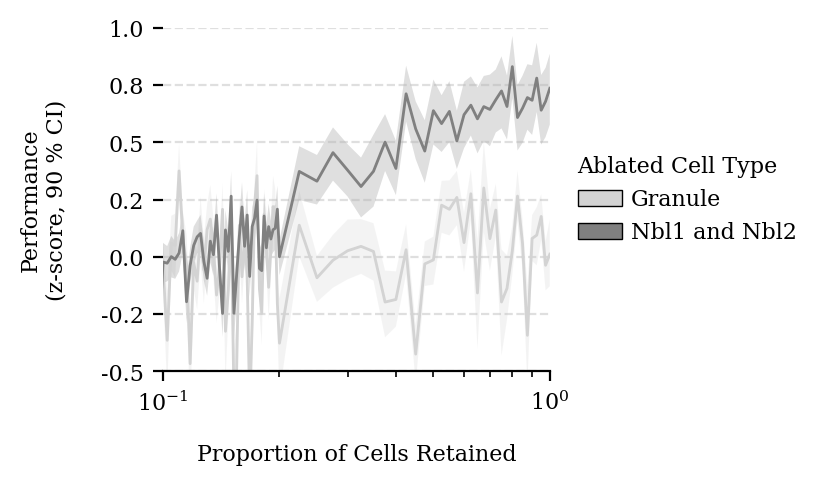

In [169]:
fig, ax = plot_summary_ci(
    df_result,
    figsize=(5, 2.5),
    x="fraction_kept",
    x_label="Proportion of Cells Retained",
    ci=0.9,
    line_width=1.01,
    log_x=True,
    hue="run_id", 
    legend_title="Ablated Cell Type",
    hue_order=["Granule", "Nbl1 and Nbl2"],
    color = ["lightgray", "gray"]
)
# ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax.xaxis.set_minor_formatter(NullFormatter())
plt.xlim(0.1, 1.0)
plt.ylim(-0.5, 1.0)
plt.show()

In [9]:
_path_of_trajectory_object = os.path.join(dataset_dir, f"scvi_dentategyrus_ablation_gene_cell_trajectory_object.pkl")
with open(_path_of_trajectory_object, "rb") as _loaded_runs_path:
    trajectory_object = pickle.load(_loaded_runs_path) 
little = trajectory_object.get_trajectory("less_complex_2", False)

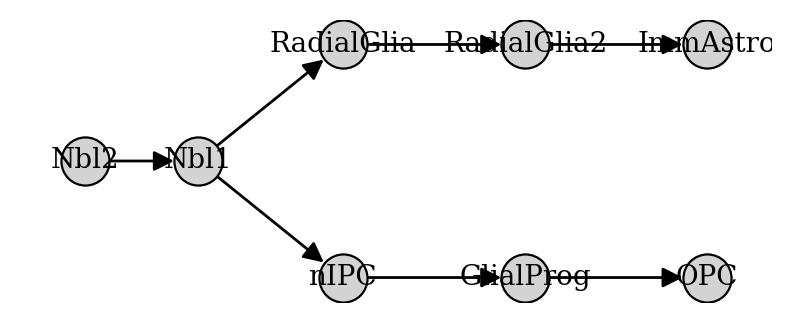

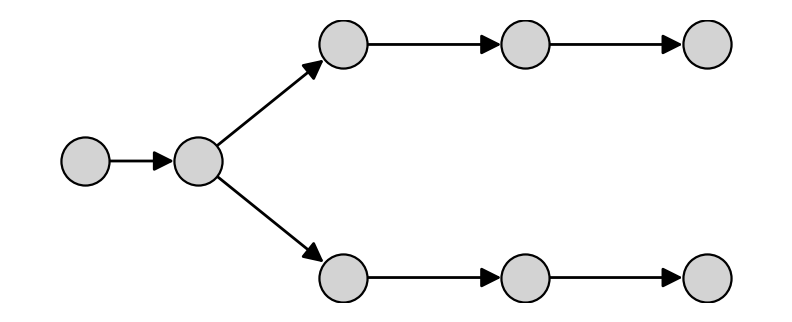

In [10]:
little.plot_trajectory(
    title=None, 
    figsize=(4,1.5),
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    label_offset=0
)
little.plot_trajectory(
    title=None, 
    figsize=(4,1.5),
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    label_offset=800
)

In [170]:
df_result = pd.DataFrame()

for run_id in ['gene']:
    df_result_ = (
        df_sctram_by_dataset[run_id].groupby("trajectory", group_keys=False)
          .apply(
              lambda g: normalize_and_align(g, metric_direction_dict),
              include_groups=True
          )
          .reset_index(drop=True)
    )
    df_result = pd.concat([df_result, df_result_])

df_result = df_result[df_result["trajectory"] == "less_complex_2"]
df_result = df_result.reset_index()
df_result["trajectory"].unique()

array(['less_complex_2'], dtype=object)

In [171]:
df_result["fraction_kept"] = 1 - df_result["fraction"]

In [174]:
# Legend for placeholder to keep the figusize consistent with above

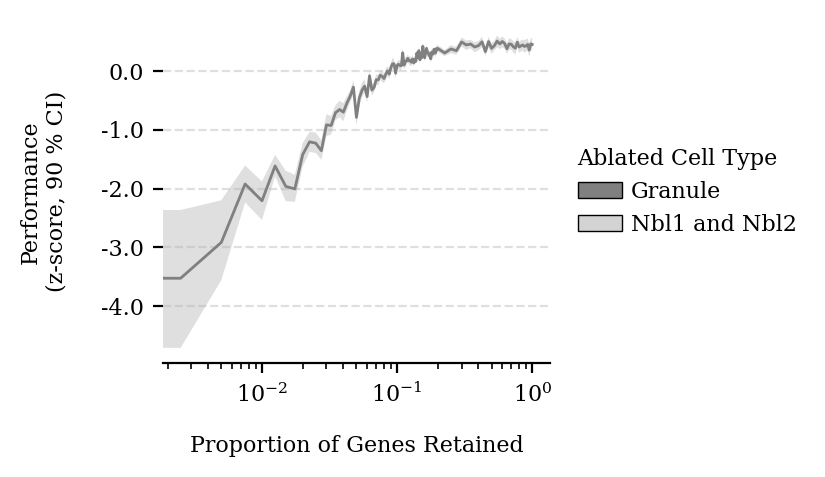

In [177]:
df_result["run_id"] = "Granule"
fig, ax = plot_summary_ci(
    df_result,
    figsize=(5, 2.5),
    x="fraction_kept",
    x_label="Proportion of Genes Retained",
    ci=0.9,
    line_width=1.01,
    log_x=True,
    hue="run_id", 
    legend_title="Ablated Cell Type",
    hue_order=["Granule", "Nbl1 and Nbl2"],
    color = ["gray", "lightgray", ]
)
# ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
# ax.xaxis.set_minor_formatter(NullFormatter())
# plt.xlim(0.1, 1.0)
# plt.ylim(-0.5, 1.0)
plt.show()

In [179]:
# umap of the whole data maybe?

In [183]:
pickle_paths_path = os.path.join(dataset_dir, f"scvi_dentategyrus_incremental_with_callback_paths.pkl")
with open(pickle_paths_path, "rb") as _loaded_runs_path:
    incremental_paths = pickle.load(_loaded_runs_path) 

In [192]:
latent = ad.read_h5ad(incremental_paths[max(incremental_paths.keys())])
adata = ad.read_h5ad('/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/scvi_dentategyrus_incremental_with_callback_training_anndata.h5ad')
latent.obs = adata.obs.copy()
del adata
gc.collect()

215356

In [193]:
sc.pp.neighbors(latent, n_neighbors=50)  # use latent space in .X
sc.tl.umap(latent)

In [212]:
def cr_calc(adata_cr, root_cell_type, i, label_obs, title, color):
    sc.tl.pca(adata_cr, n_comps=7, svd_solver='arpack')
    sce.tl.palantir(adata_cr, n_components=10, knn=30)

    root_cells = adata_cr.obs_names[adata_cr.obs[label_obs] == root_cell_type]
    if len(root_cells) == 0:
        raise ValueError(f"No cells found with LVL3 == {root_cell_type}")
    start_cell = root_cells[i]
    
    pr_res = sce.tl.palantir_results(
        adata_cr,
        early_cell=start_cell,
        ms_data="X_palantir_multiscale",
        knn=30,
        num_waypoints=1200,
        n_jobs=-1
    )
    adata_cr.obs["palantir_pseudotime"] = pr_res.pseudotime

    # Initialize and compute the PseudotimeKernel
    pk = cr.kernels.PseudotimeKernel(adata_cr, time_key='palantir_pseudotime')
    pk.compute_transition_matrix()
    return pk

In [213]:
pk = cr_calc(latent, "Nbl2", i=0, label_obs="ClusterName", title="", color="ClusterName")

Sampling and flocking waypoints...
Time for determining waypoints: 0.049204540252685544 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.865443746248881 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9988
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/18213 [00:00<?, ?cell/s]

    Finish (0:00:07)


Using precomputed projection `adata.obsm['T_fwd_umap']`


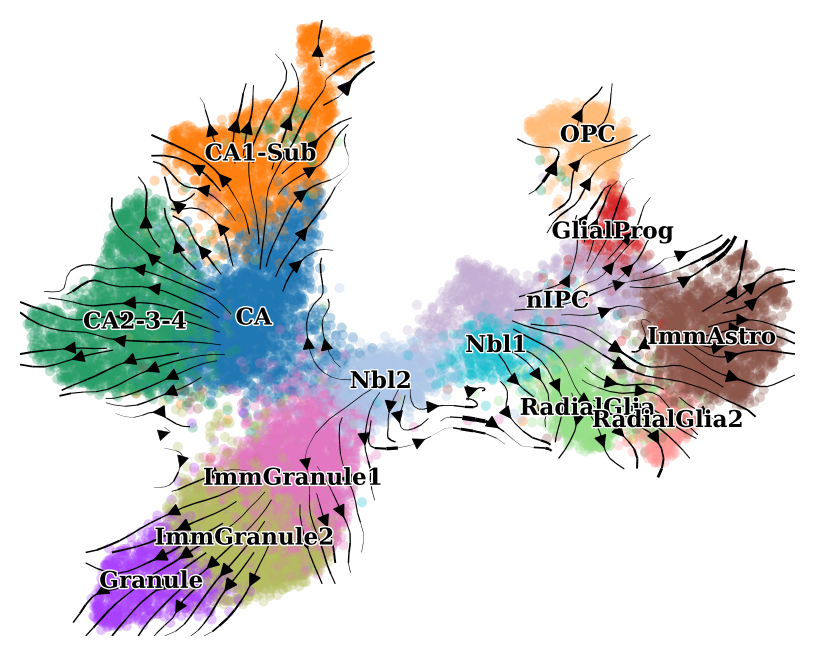

In [237]:
plt.figure(figsize=(5, 4))
pk.plot_projection(basis='umap', recompute=False, color="ClusterName", colorbar=False, title="", ax=plt.gca(), legend_fontsize="small", legend_loc='on data')
plt.show()

In [ ]:
colors = pk.adata.uns['ClusterName_colors'].copy()
latent.uns["ClusterName_colors"] = colors

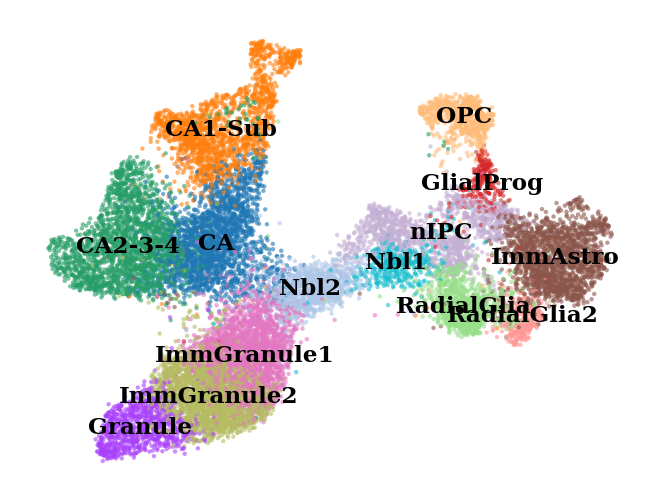

In [240]:
plt.figure(figsize=(4, 3))
sc.pl.umap(latent, color="ClusterName", title="", ax=plt.gca(), legend_fontsize="small", frameon=False, alpha=0.6, s=10, legend_loc='on data') 
plt.show()